# Predicción de ventas netas

### Ventas - devolciones por cada día

In [2]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Cargar ambos resultados de test
ventas_test = pd.read_csv('/content/drive/MyDrive/TFM_Prediccion_Ventas_RandomForest.csv')
devoluc_test = pd.read_csv('/content/drive/MyDrive/TFM_Prediccion_Devolu_RandomForest.csv')

print('VENTAS: \n')
display(ventas_test)
print('\n')
print('DEVOLUCIONES: \n')
display(devoluc_test)

VENTAS: 



,date,daily_sales,month,day_of_month,day_of_week,is_weekend,sales_lag_1,sales_lag_7,rolling_mean_7,rolling_mean_30,trend_1_vs_7,actual_sales,predicted_sales
0,2011-11-09,62359.13,11,9,2,0,54617.93,28809.90,54135.508571,44988.828000,25808.03,62359.13,56133.014861
1,2011-11-10,68593.52,11,10,3,0,62359.13,44826.29,58928.255714,44577.919000,17532.84,68593.52,54300.348913
2,2011-11-11,52808.40,11,11,4,0,68593.52,62590.96,62323.574286,44902.256000,6002.56,52808.40,51077.089998
3,2011-11-13,32213.29,11,13,6,1,52808.40,61799.62,60926.065714,44900.690333,-8991.22,32213.29,25367.900121
4,2011-11-15,58121.76,11,15,1,0,111348.61,84150.01,66584.412857,47756.211000,27198.60,58121.76,52789.962414
5,2011-11-16,62258.29,11,16,2,0,58121.76,54617.93,62866.091429,48035.987667,3503.83,62258.29,44974.955633
6,2011-11-17,58531.66,11,17,3,0,62258.29,62359.13,63957.571429,49096.034667,-100.84,58531.66,44099.867122
7,2011-11-18,49595.48,11,18,4,0,58531.66,68593.52,63410.790000,49857.487000,-10061.86,49595.48,43139.784280
8,2011-11-20,32971.76,11,20,6,1,49595.48,52808.40,60696.784286,50341.922333,-3212.92,32971.76,24763.437999
9,2011-11-21,48538.76,11,21,0,0,32971.76,32213.29,57862.978571,50725.596000,758.47,48538.76,46908.803238




DEVOLUCIONES: 



,date,daily_returns,month,day_of_month,day_of_week,is_weekend,returns_lag_1,returns_lag_7,rolling_mean_7_returns,rolling_mean_30_returns,trend_1_vs_7_returns,actual_returns,predicted_returns
0,2011-11-09,978.34,11,9,2,0,1019.39,601.66,929.261429,972.287667,417.73,978.34,1118.660205
1,2011-11-10,520.65,11,10,3,0,978.34,614.75,983.072857,986.177000,363.59,520.65,1103.594300
2,2011-11-11,319.48,11,11,4,0,520.65,2537.17,969.630000,676.669667,-2016.52,319.48,909.529647
3,2011-11-12,0.00,11,12,5,1,319.48,0.00,652.817143,603.904667,319.48,0.00,57.857328
4,2011-11-13,83.10,11,13,6,1,0.00,33.94,652.817143,591.271000,-33.94,83.10,123.300809
5,2011-11-15,149.04,11,15,1,0,724.93,1019.39,520.841429,600.785333,-294.46,149.04,828.045350
6,2011-11-16,1531.47,11,16,2,0,149.04,978.34,396.505714,602.436000,-829.30,1531.47,812.927860
7,2011-11-17,383.41,11,17,3,0,1531.47,520.65,475.524286,529.921333,1010.82,383.41,892.385456
8,2011-11-18,857.38,11,18,4,0,383.41,319.48,455.918571,537.400000,63.93,857.38,757.949056
9,2011-11-19,0.00,11,19,5,1,857.38,0.00,532.761429,550.741333,857.38,0.00,77.783938


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

resultados_caja_neta = []

# Unir y restar
df_mes_objetivo = pd.merge(ventas_test, devoluc_test, on='date')

# Ventas reales
df_mes_objetivo['real_final_sales'] = df_mes_objetivo['actual_sales'] - df_mes_objetivo['actual_returns']
display(df_mes_objetivo[['date', 'actual_sales', 'actual_returns', 'real_final_sales',]])

# Predicciones
df_mes_objetivo['predicted_final_sales'] = df_mes_objetivo['predicted_sales'] - df_mes_objetivo['predicted_returns']
display(df_mes_objetivo[['date', 'predicted_sales', 'predicted_returns', 'predicted_final_sales']])

mae = mean_absolute_error(df_mes_objetivo['real_final_sales'], df_mes_objetivo['predicted_final_sales'])
rmse = np.sqrt(mean_squared_error(df_mes_objetivo['real_final_sales'], df_mes_objetivo['predicted_final_sales']))
r2 = r2_score(df_mes_objetivo['real_final_sales'], df_mes_objetivo['predicted_final_sales'])

# 4. Guardar resultados
resultados_caja_neta.append({
    "Modelo": 'Random Forest',
    "MAE Neto (£)": mae,
    "RMSE Neto (£)": rmse,
    "R2 Neto": r2
})

# 5. Mostrar ranking final
df_res_netos = pd.DataFrame(resultados_caja_neta).sort_values(by="RMSE Neto (£)", ascending=True)

print("\n" + "="*80)
print(" RANKING DEFINITIVO: PRECISIÓN EN EL FLUJO DE CAJA NETO ")
print("="*80)
display(df_res_netos.round(2))

,date,actual_sales,actual_returns,real_final_sales
0,2011-11-09,62359.13,978.34,61380.79
1,2011-11-10,68593.52,520.65,68072.87
2,2011-11-11,52808.40,319.48,52488.92
3,2011-11-13,32213.29,83.10,32130.19
4,2011-11-15,58121.76,149.04,57972.72
5,2011-11-16,62258.29,1531.47,60726.82
6,2011-11-17,58531.66,383.41,58148.25
7,2011-11-18,49595.48,857.38,48738.10
8,2011-11-20,32971.76,51.86,32919.90
9,2011-11-21,48538.76,1503.22,47035.54


,date,predicted_sales,predicted_returns,predicted_final_sales
0,2011-11-09,56133.014861,1118.660205,55014.354656
1,2011-11-10,54300.348913,1103.594300,53196.754613
2,2011-11-11,51077.089998,909.529647,50167.560351
3,2011-11-13,25367.900121,123.300809,25244.599313
4,2011-11-15,52789.962414,828.045350,51961.917063
5,2011-11-16,44974.955633,812.927860,44162.027773
6,2011-11-17,44099.867122,892.385456,43207.481666
7,2011-11-18,43139.784280,757.949056,42381.835225
8,2011-11-20,24763.437999,164.500136,24598.937863
9,2011-11-21,46908.803238,913.585323,45995.217915



 RANKING DEFINITIVO: PRECISIÓN EN EL FLUJO DE CAJA NETO 


,Modelo,MAE Neto (£),RMSE Neto (£),R2 Neto
0,Random Forest,11233.63,14223.47,0.16


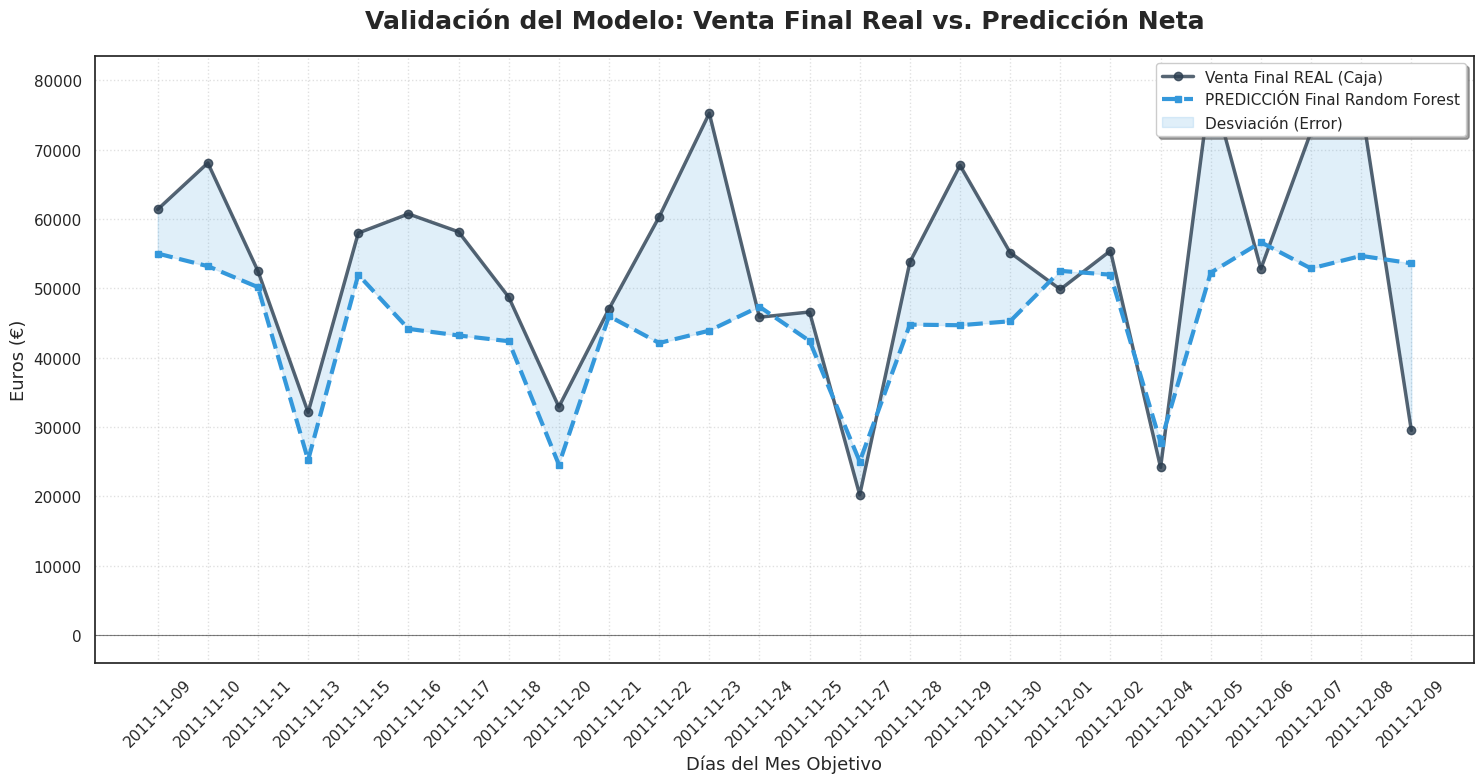

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo profesional
sns.set_theme(style="white")
plt.figure(figsize=(15, 8))

# 2. Dibujar la Venta Final Real (Línea de referencia)
plt.plot(df_mes_objetivo['date'], df_mes_objetivo['real_final_sales'],
         label='Venta Final REAL (Caja)', color='#2C3E50',
         linewidth=2.5, marker='o', markersize=6, alpha=0.8)

# 3. Dibujar la Predicción Final (Línea del modelo)
plt.plot(df_mes_objetivo['date'], df_mes_objetivo['predicted_final_sales'],
         label='PREDICCIÓN Final Random Forest', color='#3498DB',
         linewidth=3, linestyle='--', marker='s', markersize=4)

# 4. Sombreado entre ambas (Visualiza el error de predicción)
plt.fill_between(df_mes_objetivo['date'],
                 df_mes_objetivo['real_final_sales'],
                 df_mes_objetivo['predicted_final_sales'],
                 color='#3498DB', alpha=0.15, label='Desviación (Error)')

# 5. Anotaciones y Estética
plt.title('Validación del Modelo: Venta Final Real vs. Predicción Neta', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Días del Mes Objetivo', fontsize=13)
plt.ylabel('Euros (€)', fontsize=13)

# Formatear el eje X para que no se amontonen las fechas
plt.xticks(rotation=45)

# Añadir leyenda y cuadrícula
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Añadir una línea horizontal en 0 si hubiera valores negativos (opcional)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()